# Bepaling van soortelijke warmte van water


# Introductie

Water heeft een enorme buffercapaciteit: je moet veel energie toevoegen om de temperatuur van water een graad te verwarmen. In dit practicum gaan we de soortelijke warmte van water bepalen door een bekende hoeveelheid water te verwarmen met een bekende hoeveelheid energie, en de temperatuurstijging te meten.

# Theorie

Geef hier de natuurkundige achtergrond van het onderwerp. 

# Methode en materialen

## Ontwerp
Een waterbad met bekende massa aan water wordt verwarmd met een elektrisch verwarmingselement dat een bekende hoeveelheid energie levert.
De temperatuur van het water wordt gemeten met een temperatuursensor.
Door de temperatuurstijging als functie van de tijd te meten kan de soortelijke warmte van water worden berekend.


## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Maatbeker
- Weegschaal
- Water
- Elektrisch verwarmingselement ($10 \mathrm{\Omega}$, $10 \mathrm{W}$)
- Voedingsbron 
- Thermometer of temperatuursensor
- Stopwatch of timer

```{figure} figures/cwater_setup.jpg
:width: 70%

Een schematische weergave van de opstelling
```

## Procedure
```{exercise}
1. Beschrijf de procedure die nodig is om de soortelijke warmte van water te bepalen.
2. Geef jouw beschrijving van de procedure aan een ander team, zij verzamelen voor jou de data op basis van de gegevens.
3. Voer het experiment van een ander team uit op basis van hun beschrijving.
4. Analyseer de data die het andere groepje voor jou heeft verzameld.
```
```{Procedure}
1. Weeg de lege maatbeker en noteer deze
2. Vul de maatbeker met water tot de 300mL lijn
3. Zet de met water gevulde maatbeker op de Heidolph
4. Stop de thermometer in het water van de maatbeker en noteer de beginwaarde
5. Stop de weerstand in het water in de maatbeker
6. Sluit de weerstand aan op de DC generator op de 12V aansluiting
7. Zet de Heidolph aan
8. Zet de DC generator aan met een stroom van 2.5A
9. Noteer gedurende een half uur elke minuut de temperatuur met de tijd


## Veiligheid
We maken gebruik van een $10 \mathrm{\Omega}$, $10 \mathrm{W}$ weerstand.
Deze wordt snel heet.
De bronspanning mag dan ook alleen aan wanneer de weerstand in het water zit.
Raak de weerstand niet aan tijdens het experiment.
Omdat de weerstand in het water zit, kunnen we wel het elektrisch vermogen hoger zetten zonder dat de weerstand oververhit raakt.
Het maximaal vermogen mag $40 \mathrm{W}$ zijn.
Daarbij moet de roerder wel aanstaan om de warmte goed te verdelen.



## Data analyse
1. Weeg de lege maatbeker en noteer deze; 171.6 g
2. Vul de maatbeker met water tot de 300mL lijn; konden aflezen tot 3.0 * 10^2 mL
3. Zet de met water gevulde maatbeker op de Heidolph
4. Stop de thermometer in het water van de maatbeker en noteer de beginwaarde
5. Stop de weerstand in het water in de maatbeker
6. Sluit de weerstand aan op de DC generator op de 12V aansluiting
7. Zet de Heidolph aan
8. Zet de DC generator aan met een stroom van 2.5A; we hebben gemeten op 1.5A, anders wattage te hoog, voltage kwam uit op 14.6 V
9. Noteer gedurende een half uur elke minuut in een excelbestand de temperatuur met de tijd

# Resultaten


In [2]:
#Import blah blah
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [19]:
# Hier de data en de analyse
tData = np.arange(0,901,60)                                                                             #Tijd intervallen van meting (s)
TData = np.array([20.4,21.2,22.1,23.0,23.9,24.8,25.6,26.5,27.3,28.1,28.9,29.6,30.4,31.1,31.9,32.6])     #Gemeten temperaturen (˚C)
I = 1.5     #(A)
U = 14.6    #(V)
m = 0.3     #(kg)

0.013637254899713321 20.575735293804534
5352.983466015186


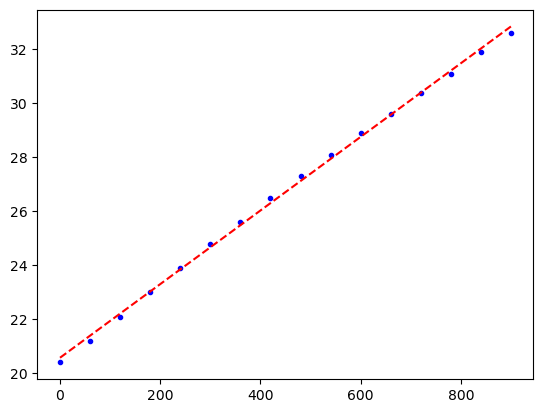

In [ ]:
T_verschil = TData[-1]-TData[0]     #Temperatuur verschil (˚C)
T_0 = TData[0]                         #Begin temperatuur (˚C)
t_verschil = tData[-1]-tData[0]      #Tijd verschil (s)
P = U * I                              #Vermogen (W)

def func(a,t,b):
    return a * t + b

popt, pcov = curve_fit(func, tData, TData, p0=[T_verschil/t_verschil,T_0])

a_fit, b_fit = popt
print(a_fit,b_fit)

c = P / (m * (a_fit))
print(c)

t_fit = np.linspace(tData.min(), tData.max(), 300)
T_fit = func(t_fit, a_fit, b_fit)

plt.plot(tData,TData,'b.')
plt.plot(t_fit,T_fit, 'r--')
# Sla figuren op met  
# 
# plt.savefig("figures/naam.png", dpi=450)



0.01363725490196066 20.575735294118203


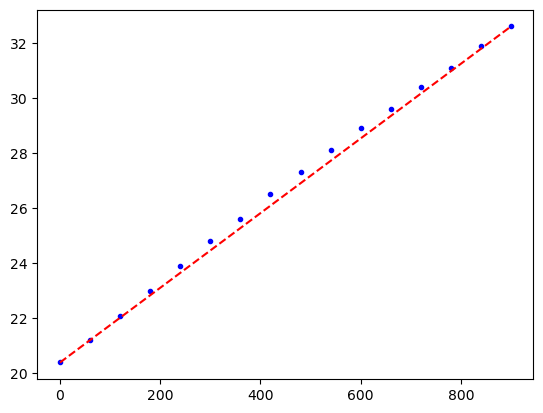

In [43]:
T_verschil = TData[-1]-TData[0]     #Temperatuur verschil (˚C)
T_0 = TData[0]                         #Begin temperatuur (˚C)
t_verschil = tData[-1]-tData[0]      #Tijd verschil (s)
P = U * I     

def func2(m,c,dT,dt):
    return m * c * (dT/dt)

popt, pcov = curve_fit(func, tData, TData, p0=[m,4186])

m_fit, c_fit = popt
print(m_fit,c_fit)

t_fit = np.linspace(tData.min(), tData.max(), 300)
T_fit = (func2(m_fit,c_fit,T_verschil,t_verschil)/(m_fit*c_fit))*t_fit + T_0

plt.plot(tData,TData,'b.')
plt.plot(t_fit,T_fit, 'r--')

# Discussie en conclusie

Hier een korte discussie en conclusie over de resultaten van het experiment en de implicaties daarvan.